In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import sys
sys.path.append("../../..")
import numpy as np
import torch
import datetime
from scipy.interpolate import interp1d

from src.causalpfn.causal_estimator import CausalEstimator

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

## Main hyperparameter
#N_DISC_VALUES = [2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30]
N_DISC_VALUES = [2]

## Discretization function
def discretize_treatment(T: np.ndarray, N: int) -> np.ndarray:
    """Returns discretized version of T. Assumes range of T is [0, 1].

    Args:
        T (np.ndarray): The raw treatment data 
        N (int): The number of discretized treatment values to use

    Returns:
        np.ndarray: The discretized treatment data
    """
    dt = 1 / (N - 1)
    T_discrete = np.round(np.array(T, dtype=np.float32) / dt) * dt

    return T_discrete

## Synthetic data generation
data_name = "ADMIT-synthetic"
# DGP from https://github.com/CausalTeam/ADMIT/blob/main
def sigmoid(t): return 1. / (1. + np.exp(-1. * t))
n, d = 2000, 6
X = np.random.uniform(-1, 1, (n, d))
x1 = X[:, 0]
x2 = X[:, 1]
x3 = X[:, 2]
x4 = X[:, 3]
x5 = X[:, 4]
x6 = X[:, 5]
# Generate treatment 
mu_1 =  (10. * np.sin(np.maximum(x1, np.maximum(x2, x3))) + np.maximum(x3, np.maximum(x4, x5))**3)/(1. + (x1 + x5)**2) + np.sin(0.5 * x3) * (1. + np.exp(x4 - 0.5 * x3)) + x3**2 + 2. * np.sin(x4) + 2.*x5 - 6.5
T = np.random.normal(mu_1, 0.5)
T = sigmoid(T)
# Generate outcomes
mu_2 = np.cos(2 * np.pi * (T - 0.5)) * (T ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
Y = np.random.normal(mu_2, 0.5)
# Generated expected potential outcomes empirically
treatment_doses = np.linspace(0, 1, 100)
effects = []
for t in treatment_doses:
    T_intervention = t * np.ones(T.shape)
    mu_2_intervention = np.cos(2 * np.pi * (T_intervention - 0.5)) * (T_intervention ** 2 + (4 * np.maximum(x1, x6) ** 3) * np.sin(x4) / (1 + 2 * x3 ** 2))
    effects.append(mu_2_intervention.mean())
effects = np.array(effects)

In [2]:
effects

array([ 8.45200086e-03,  8.33315926e-03,  7.97916473e-03,  7.39758295e-03,
        6.60094009e-03,  5.60659838e-03,  4.43658334e-03,  3.11736382e-03,
        1.67958651e-03,  1.57767048e-04, -1.41006015e-03, -2.98273051e-03,
       -4.51637358e-03, -5.96486960e-03, -7.28033495e-03, -8.41363283e-03,
       -9.31490507e-03, -9.93412109e-03, -1.02216397e-02, -1.01287791e-02,
       -9.60839120e-03, -8.61543492e-03, -7.10754410e-03, -5.04558578e-03,
       -2.39420364e-03,  8.77657558e-04,  4.79625121e-03,  9.38255606e-03,
        1.46518356e-02,  2.06132337e-02,  2.72694104e-02,  3.46162213e-02,
        4.26424441e-02,  5.13295551e-02,  6.06515590e-02,  7.05748735e-02,
        8.10582714e-02,  9.20528826e-02,  1.03502255e-01,  1.15342480e-01,
        1.27502373e-01,  1.39903728e-01,  1.52461619e-01,  1.65084776e-01,
        1.77676013e-01,  1.90132714e-01,  2.02347385e-01,  2.14208242e-01,
        2.25599872e-01,  2.36403922e-01,  2.46499847e-01,  2.55765688e-01,
        2.64078893e-01,  

In [3]:
drf = interp1d(treatment_doses, effects)

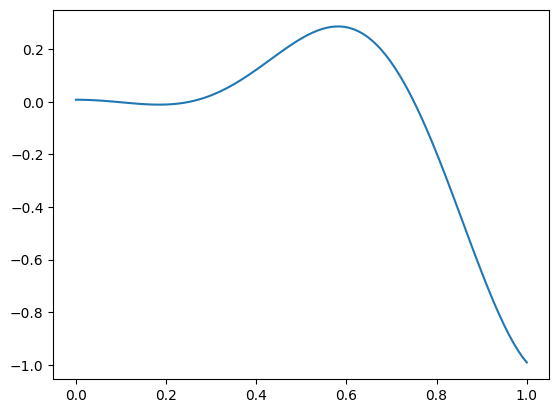

In [7]:
plt.plot(treatment_doses, drf(treatment_doses))